In [ ]:
from google.colab import files

uploaded = files.upload()


Saving smart_city_traffic_air_quality.csv to smart_city_traffic_air_quality.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("smart_city_traffic_air_quality.csv")

In [ ]:
df.head()

,city,time_of_day,traffic_volume,pm25,aqi,pollution_level
0,Chennai,Morning,1200,35.2,68,High
1,Chennai,Evening,1800,48.6,82,High
2,Bangalore,Morning,950,28.4,55,Medium
3,Bangalore,Evening,1400,39.1,70,High
4,Delhi,Morning,2100,92.5,160,Severe


In [ ]:
df.tail()

,city,time_of_day,traffic_volume,pm25,aqi,pollution_level
5,Delhi,Evening,2600,110.3,190,Severe
6,Hyderabad,Morning,800,26.7,50,Medium
7,Hyderabad,Evening,1200,34.9,65,High
8,Mumbai,Morning,1600,55.4,90,High
9,Mumbai,Evening,2000,72.8,120,Very High


In [ ]:
df.shape

(10, 6)

In [ ]:
df.columns

Index(['city', 'time_of_day', 'traffic_volume', 'pm25', 'aqi',
       'pollution_level'],
      dtype='object')

In [ ]:
df.dtypes

,0
city,object
time_of_day,object
traffic_volume,int64
pm25,float64
aqi,int64
pollution_level,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city             10 non-null     object 
 1   time_of_day      10 non-null     object 
 2   traffic_volume   10 non-null     int64  
 3   pm25             10 non-null     float64
 4   aqi              10 non-null     int64  
 5   pollution_level  10 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 612.0+ bytes


In [ ]:
df.describe()

,traffic_volume,pm25,aqi
count,10.000000,10.000000,10.00000
mean,1565.000000,54.390000,95.00000
std,563.742455,28.627665,47.07913
min,800.000000,26.700000,50.00000
25%,1200.000000,34.975000,65.75000
50%,1500.000000,43.850000,76.00000
75%,1950.000000,68.450000,112.50000
max,2600.000000,110.300000,190.00000


In [ ]:
df[['traffic_volume', 'pm25', 'aqi']].agg(['mean', 'min', 'max'])

,traffic_volume,pm25,aqi
mean,1565.0,54.39,95.0
min,800.0,26.70,50.0
max,2600.0,110.30,190.0


In [ ]:
df.isnull().sum()

,0
city,0
time_of_day,0
traffic_volume,0
pm25,0
aqi,0
pollution_level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().mean() * 100

,0
city,0.0
time_of_day,0.0
traffic_volume,0.0
pm25,0.0
aqi,0.0
pollution_level,0.0


In [ ]:
df['city'].unique()

array(['Chennai', 'Bangalore', 'Delhi', 'Hyderabad', 'Mumbai'],
      dtype=object)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['traffic_volume'].describe()

,traffic_volume
count,10.000000
mean,1565.000000
std,563.742455
min,800.000000
25%,1200.000000
50%,1500.000000
75%,1950.000000
max,2600.000000


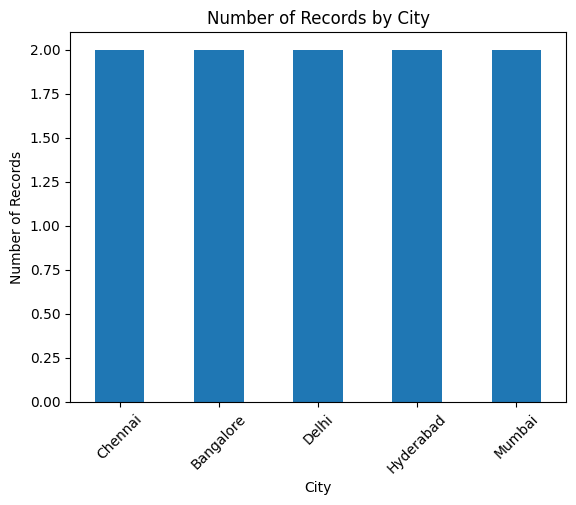

In [ ]:
df['city'].value_counts().plot(kind='bar')

plt.title("Number of Records by City")
plt.xlabel("City")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

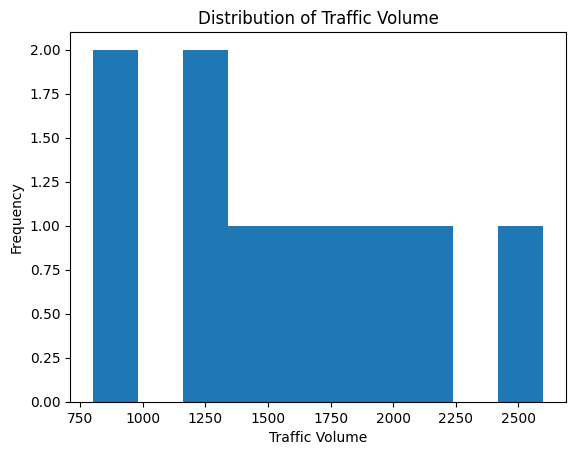

In [ ]:
plt.hist(df['traffic_volume'], bins=10)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

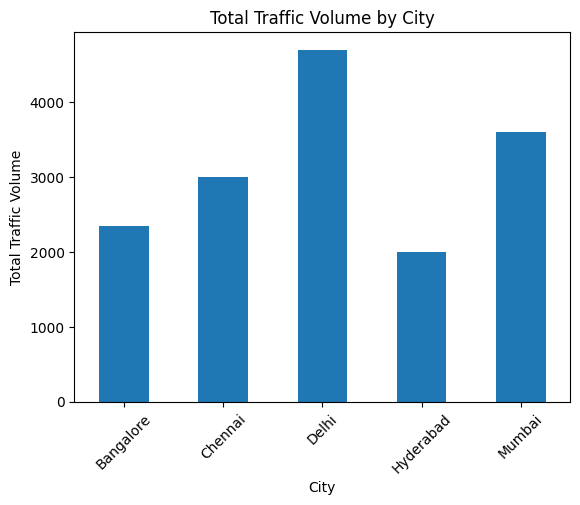

In [ ]:
df.groupby('city')['traffic_volume'].sum().plot(kind='bar')

plt.title("Total Traffic Volume by City")
plt.xlabel("City")
plt.ylabel("Total Traffic Volume")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.columns.tolist()

['city', 'time_of_day', 'traffic_volume', 'pm25', 'aqi', 'pollution_level']

### Visualization 1: Average Traffic Volume by City

Purpose:
To compare the average traffic volume across different cities.

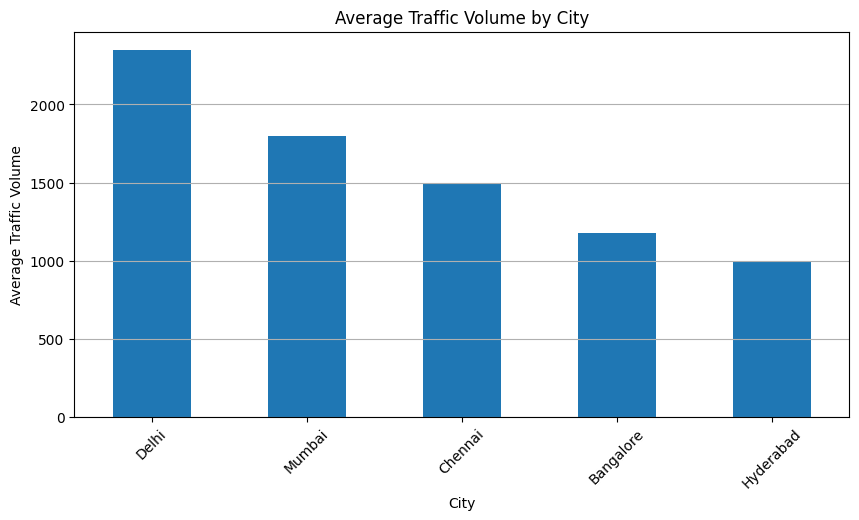

In [ ]:
import matplotlib.pyplot as plt

traffic_by_city = df.groupby('city')['traffic_volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
traffic_by_city.plot(kind='bar')

plt.title('Average Traffic Volume by City')
plt.xlabel('City')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Visualization 2: Average PM2.5 by City

Purpose:
To compare the average PM2.5 level across different cities.

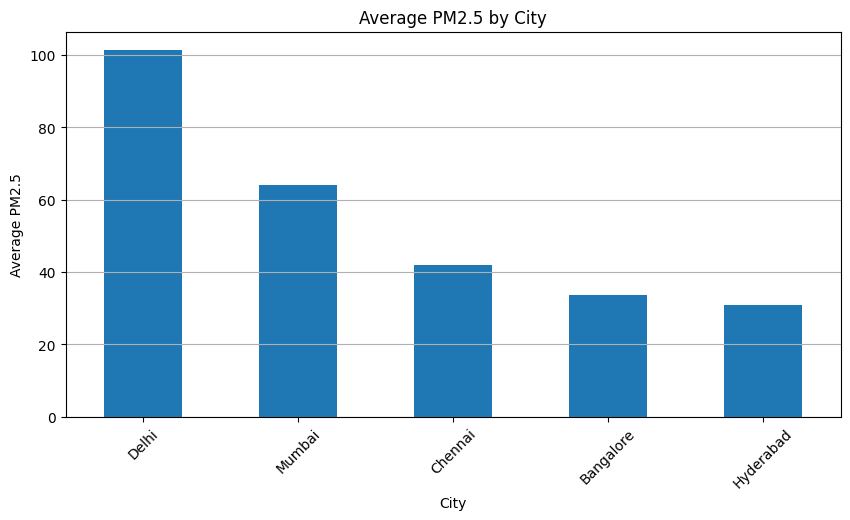

In [ ]:
pm25_by_city = df.groupby('city')['pm25'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
pm25_by_city.plot(kind='bar')

plt.title('Average PM2.5 by City')
plt.xlabel('City')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Visualization 3: Average AQI by City

Purpose:
To compare the average Air Quality Index (AQI) across different cities.

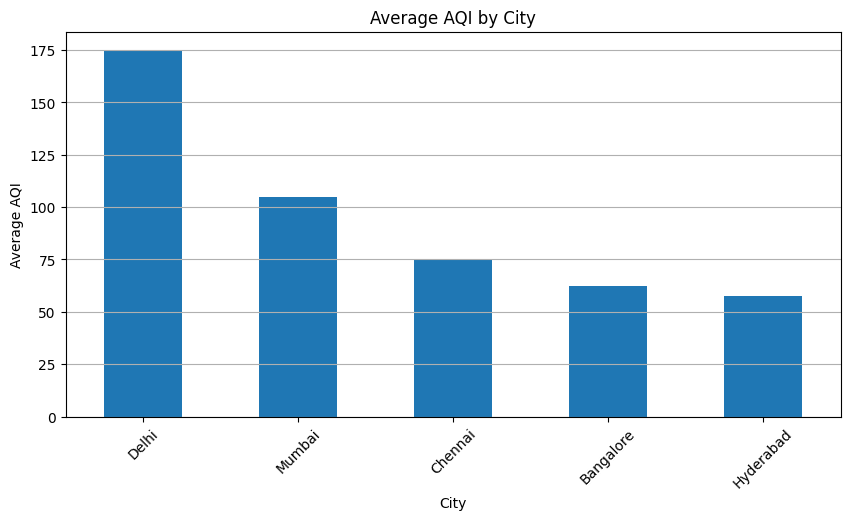

In [ ]:
aqi_by_city = df.groupby('city')['aqi'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
aqi_by_city.plot(kind='bar')

plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Visualization 4: Traffic Volume vs AQI

Purpose:
To examine the relationship between traffic volume and Air Quality Index (AQI).

### Visualization 5: PM2.5 vs AQI

Purpose:
To examine the relationship between PM2.5 concentration and Air Quality Index (AQI).

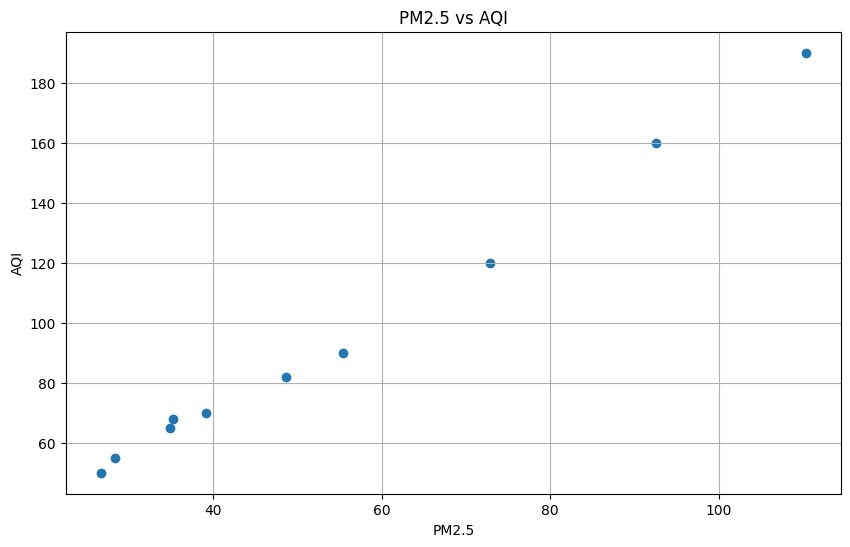

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df['pm25'], df['aqi'])

plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.grid(True)

plt.show()

In [ ]:
correlation_matrix = df[['traffic_volume', 'pm25', 'aqi']].corr()

correlation_matrix

,traffic_volume,pm25,aqi
traffic_volume,1.000000,0.955241,0.940701
pm25,0.955241,1.000000,0.996695
aqi,0.940701,0.996695,1.000000


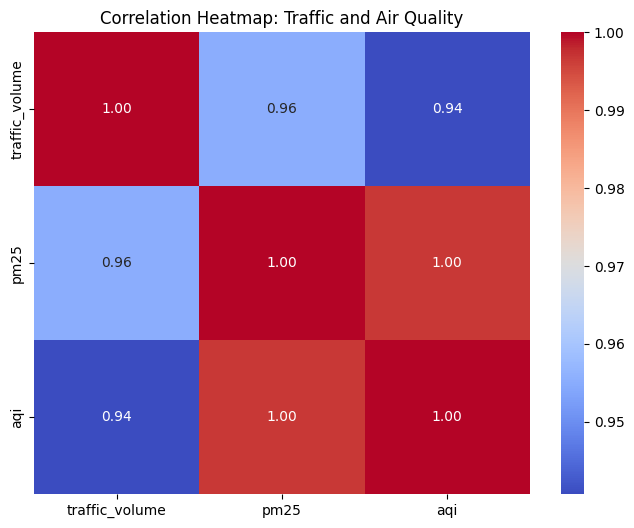

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap: Traffic and Air Quality')
plt.show()

In [ ]:
print("TRAFFIC VOLUME")
print("Mean:", df['traffic_volume'].mean())
print("Median:", df['traffic_volume'].median())
print("Minimum:", df['traffic_volume'].min())
print("Maximum:", df['traffic_volume'].max())
print("Standard Deviation:", df['traffic_volume'].std())



TRAFFIC VOLUME
Mean: 1565.0
Median: 1500.0
Minimum: 800
Maximum: 2600
Standard Deviation: 563.742454987697


In [ ]:
print("\nPM2.5")
print("Mean:", df['pm25'].mean())
print("Median:", df['pm25'].median())
print("Minimum:", df['pm25'].min())
print("Maximum:", df['pm25'].max())
print("Standard Deviation:", df['pm25'].std())




PM2.5
Mean: 54.39
Median: 43.85
Minimum: 26.7
Maximum: 110.3
Standard Deviation: 28.62766532957625


In [ ]:
print("\nAQI")
print("Mean:", df['aqi'].mean())
print("Median:", df['aqi'].median())
print("Minimum:", df['aqi'].min())
print("Maximum:", df['aqi'].max())
print("Standard Deviation:", df['aqi'].std())


AQI
Mean: 95.0
Median: 76.0
Minimum: 50
Maximum: 190
Standard Deviation: 47.07912960585024


In [ ]:
df.corr(numeric_only=True)

,traffic_volume,pm25,aqi
traffic_volume,1.000000,0.955241,0.940701
pm25,0.955241,1.000000,0.996695
aqi,0.940701,0.996695,1.000000
